# Astroquímica da Nebulosa de Órion — Identificação de moléculas na região OMC-1

**Autores:** Thayllan Anthony de Oliveira · Rafael Ramon Ferreira
**Instituição:** Instituto Federal do Triângulo Mineiro (IFTM)

Este notebook acompanha o artigo submetido à revista *Physicæ Organum* (UnB) e foi
escrito com finalidade **didática**: cada etapa está comentada para que estudantes de
licenciatura (Química, Física, Ciências) possam reproduzir, entender e adaptar a análise.

## O que vamos fazer

Partindo de um cubo de dados do observatório **ALMA** (formato FITS), vamos:

1. **Carregar** o cubo de dados tridimensional (2 eixos espaciais + 1 eixo de frequência).
2. **Mapear** espacialmente a nuvem e localizar o pixel de emissão máxima.
3. **Extrair** o espectro de rádio nesse pixel.
4. **Identificar** as moléculas (*Line ID*) consultando os catálogos JPL e CDMS.
5. **Filtrar** os candidatos com um critério físico (energia do nível superior).
6. **Converter** a posição do pixel em coordenadas celestes (RA/Dec).

> **Pré-requisitos:** noções básicas de Python (listas, funções, gráficos) e de
> espectroscopia (o que é uma linha de emissão). Não é necessário conhecimento prévio
> de astronomia — os conceitos são introduzidos ao longo do caminho.

## Como executar

Você pode rodar tanto no **Google Colab** quanto localmente. Basta ajustar a variável
`PASTA_DADOS` na célula de configuração. Cada bloco de código gera, quando aplicável,
uma figura salva na pasta `figuras/`, na mesma pasta do notebook.

## Etapa 0 — Configuração do ambiente

Instalamos e importamos as bibliotecas. Trabalhamos com poucas ferramentas, todas
gratuitas e amplamente usadas em astronomia:

| Biblioteca | Para que serve |
|---|---|
| `numpy` | operações numéricas com matrizes (o cubo de dados é uma matriz 3D) |
| `matplotlib` | geração dos gráficos |
| `pandas` | organização das tabelas de moléculas |
| `astropy` | leitura de arquivos FITS e conversão de coordenadas (WCS) |
| `astroquery` | consulta aos catálogos moleculares JPL/CDMS via Splatalogue |

> No Colab, `astroquery` normalmente não vem instalado; por isso a primeira linha o instala.

In [1]:
# Instala a biblioteca de consulta a catálogos (necessário no Google Colab).
# O "-q" deixa a saída silenciosa. Se já estiver instalada, nada acontece.
%pip install -q astroquery

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS
from astropy import units as u
from astroquery.splatalogue import Splatalogue
from matplotlib.ticker import AutoMinorLocator

from astropy.utils.data import download_file
import shutil


# Estilo SuperMongo: serifada, ticks para dentro nos 4 lados, sem grade.
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.family": "serif",
    "mathtext.fontset": "dejavuserif",
    "font.size": 12,
    "axes.linewidth": 1.2,      # moldura mais firme
    "axes.grid": False,         # SuperMongo não usa grade
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,          # ticks nos 4 lados
    "ytick.right": True,
    "xtick.major.size": 7, "xtick.minor.size": 4,
    "ytick.major.size": 7, "ytick.minor.size": 4,
    "xtick.major.width": 1.0, "ytick.major.width": 1.0,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
})

def estilo_sm(ax):
    """Aplica o acabamento SuperMongo a um eixo: minor ticks e moldura fechada."""
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(which="both", direction="in", top=True, right=True)
    for lado in ax.spines.values():
        lado.set_linewidth(1.2)

print("Ambiente configurado com sucesso (estilo SuperMongo).")

Note: you may need to restart the kernel to use updated packages.
Ambiente configurado com sucesso (estilo SuperMongo).


### Onde ficam os dados e as figuras

Definimos dois caminhos em um único lugar, para não repetir strings pelo notebook:

- `PASTA_DADOS`: onde o cubo FITS será baixado/lido.
- `PASTA_FIGURAS`: onde as figuras serão salvas (`figuras/`, ao lado do notebook).

Se estiver no **Colab** e quiser guardar os dados no seu Drive, monte-o com o código
comentado abaixo e ajuste `PASTA_DADOS`.

In [2]:
# --- Ambiente local (padrão) ---
PASTA_DADOS = "dados"
PASTA_FIGURAS = "figuras"

# --- Alternativa: Google Drive no Colab (descomente se desejar) ---
# from google.colab import drive
# drive.mount("/content/drive")
# PASTA_DADOS = "/content/drive/MyDrive/OMC-1/dados"

os.makedirs(PASTA_DADOS, exist_ok=True)
os.makedirs(PASTA_FIGURAS, exist_ok=True)

ARQUIVO_CUBO = os.path.join(PASTA_DADOS, "orion_cubo.fits")
print("Dados  ->", PASTA_DADOS)
print("Figuras->", PASTA_FIGURAS)

Dados  -> dados
Figuras-> figuras


## Etapa 1 — Download do cubo de dados do ALMA

O arquivo `OMC-1_Region5_sci.spw18.cube.I.pbcor.fits` é um **cubo de dados**: imagine
uma pilha de imagens do céu, uma para cada frequência observada. Ele vem do arquivo
público do ALMA.

> O download só acontece se o arquivo ainda não existir localmente — assim você não
> baixa de novo a cada execução.

In [3]:
URL_ALMA = "https://almascience.eso.org/dataPortal/member.uid___A001_X1292_X14a.OMC-1_Region5_sci.spw18.cube.I.pbcor.fits"

if not os.path.exists(ARQUIVO_CUBO):
    print("Baixando o cubo de dados do ALMA...")
    # --progress=bar:force mostra a barra mesmo dentro do notebook
    !wget --progress=bar:force -O "$ARQUIVO_CUBO" "$URL_ALMA"
    print("Download concluído.")
else:
    print("Cubo já existe localmente — pulando o download.")

Cubo já existe localmente — pulando o download.


## Etapa 2 — Carregando o cubo e entendendo sua estrutura

Um arquivo FITS tem duas partes: o **cabeçalho** (metadados: dimensões, frequência de
referência, coordenadas) e os **dados** (a matriz numérica).

A dimensão do cubo do ALMA costuma ser `(1, N_freq, N_y, N_x)` — o primeiro eixo é a
*polarização*, que não usaremos. Vamos removê-lo para ficar com um cubo 3D limpo:
`(N_freq, N_y, N_x)`.

Para evitar reabrir o arquivo várias vezes, criamos uma **função** que carrega o cubo e
já devolve o cabeçalho junto.

In [4]:
def carregar_cubo(caminho):
    """Le um cubo FITS do ALMA e devolve (cubo_3d, cabecalho).

    Remove o eixo de polarizacao, se existir, deixando (N_freq, N_y, N_x).
    """
    with fits.open(caminho) as hdul:
        hdul.info()                      # imprime a estrutura do arquivo
        dados = hdul[0].data
        cabecalho = hdul[0].header
    # data.ndim == 4  ->  (pol, freq, y, x); pegamos o indice 0 da polarizacao.
    cubo_3d = dados[0] if dados.ndim == 4 else dados
    return cubo_3d, cabecalho


cubo, header = carregar_cubo(ARQUIVO_CUBO)
print("\nDimensões do cubo 3D (freq, y, x):", cubo.shape)

Filename: dados/orion_cubo.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      92   (288, 320, 3838, 1)   float32   

Dimensões do cubo 3D (freq, y, x): (3838, 320, 288)


### Construindo o eixo de frequência

O cabeçalho guarda três números que descrevem o eixo espectral, seguindo a convenção
**WCS** (*World Coordinate System*):

- `CRVAL3`: frequência no pixel de referência (em Hz);
- `CDELT3`: quanto a frequência muda de um canal para o próximo (em Hz);
- `CRPIX3`: qual canal é o de referência.

Com eles convertemos o "número do canal" em **frequência física** (GHz). Encapsulamos
isso em uma função porque será reutilizada nos próximos gráficos.

In [5]:
def eixo_frequencia_ghz(header, n_canais):
    """Converte numeros de canal em frequencia (GHz) usando o WCS do cabecalho."""
    crval = header["CRVAL3"]        # frequencia de referencia (Hz)
    cdelt = header["CDELT3"]        # passo entre canais (Hz)
    crpix = header["CRPIX3"]        # canal de referencia (base 1)
    canais = np.arange(n_canais)
    freq_hz = crval + (canais - (crpix - 1)) * cdelt
    return freq_hz / 1e9            # Hz -> GHz


freq_ghz = eixo_frequencia_ghz(header, cubo.shape[0])
print(f"Faixa de frequência observada: {freq_ghz.min():.3f} a {freq_ghz.max():.3f} GHz")
print(f"Número de canais espectrais: {cubo.shape[0]}")

Faixa de frequência observada: 232.141 a 234.014 GHz
Número de canais espectrais: 3838


## Etapa 3 — Localizando a fonte: mapa espacial e pixel de emissão máxima

A emissão da nuvem não está no centro da imagem. Para achar o ponto mais brilhante,
colapsamos o eixo de frequência tomando, para cada pixel do céu, a **intensidade máxima**
ao longo de todos os canais. Isso gera um **mapa 2D** (uma "foto" da nuvem).

Em seguida, `np.nanargmax` encontra automaticamente as coordenadas `(x, y)` do pixel
mais intenso — a nossa **"Região 5"**.

> Usamos as versões `nan*` (`nanmax`, `nanargmax`) porque cubos do ALMA contêm pixels
> vazios marcados como `NaN` nas bordas; essas funções os ignoram.

In [6]:
# Mapa de intensidade maxima: "achata" o eixo espectral (axis=0).
with np.errstate(all="ignore"):          # bordas do cubo são todas-NaN; ignoramos o aviso
    mapa_max = np.nanmax(np.where(np.isfinite(cubo), cubo, np.nan), axis=0)

# Coordenadas (y, x) do pixel mais brilhante de todo o cubo.
y_pico, x_pico = np.unravel_index(np.nanargmax(mapa_max), mapa_max.shape)
print(f"Pixel de emissão máxima -> X = {x_pico}, Y = {y_pico}")

# Espectro extraido exatamente nesse pixel.
espectro_pico = cubo[:, y_pico, x_pico]
fluxo_pico = np.nanmax(espectro_pico)
print(f"Fluxo no pico: {fluxo_pico:.2f} Jy/beam")

Pixel de emissão máxima -> X = 110, Y = 289
Fluxo no pico: 13.30 Jy/beam


/var/folders/1m/whc0_ck14x37_09_jw61tblc0000gn/T/ipykernel_24369/3108620642.py:3: RuntimeWarning: All-NaN slice encountered
  mapa_max = np.nanmax(np.where(np.isfinite(cubo), cubo, np.nan), axis=0)


In [7]:
from scipy.signal import find_peaks

def detectar_picos(freq_ghz, espectro, n_sigma=6, separacao_ghz=0.05):
    """Detecta picos de emissão acima de n_sigma vezes o ruído robusto (MAD).

    Retorna (indices, frequencias_ghz, alturas) ordenados por frequência.
    """
    esp = np.nan_to_num(espectro, nan=0.0)
    mediana = np.median(esp)
    mad = np.median(np.abs(esp - mediana))          # desvio absoluto mediano
    ruido = 1.4826 * mad                             # MAD -> sigma equivalente
    limiar = mediana + n_sigma * ruido
    dist_canais = max(1, int(separacao_ghz / np.median(np.diff(freq_ghz))))
    idx, props = find_peaks(esp, height=limiar, distance=dist_canais, prominence=ruido)
    return idx, freq_ghz[idx], props["peak_heights"]

idx_picos, freq_picos, alt_picos = detectar_picos(freq_ghz, espectro_pico)

print(f"{len(freq_picos)} picos detectados (acima de 6σ do ruído):")
for f, a in zip(freq_picos, alt_picos):
    print(f"  ν = {f:.4f} GHz   |   fluxo = {a:.2f} Jy/beam")

5 picos detectados (acima de 6σ do ruído):
  ν = 232.4132 GHz   |   fluxo = 9.51 Jy/beam
  ν = 232.9401 GHz   |   fluxo = 13.30 Jy/beam
  ν = 233.5657 GHz   |   fluxo = 0.80 Jy/beam
  ν = 233.7718 GHz   |   fluxo = 1.03 Jy/beam
  ν = 234.0062 GHz   |   fluxo = 4.53 Jy/beam


### Figura — mapa espacial + espectro no pixel de pico

Geramos a figura de dois painéis usada no artigo: à esquerda o mapa da nuvem com o pixel
de pico destacado; à direita o espectro extraído nesse ponto. A figura é salva em
`figuras/fig3_mapa_espectro.png`.

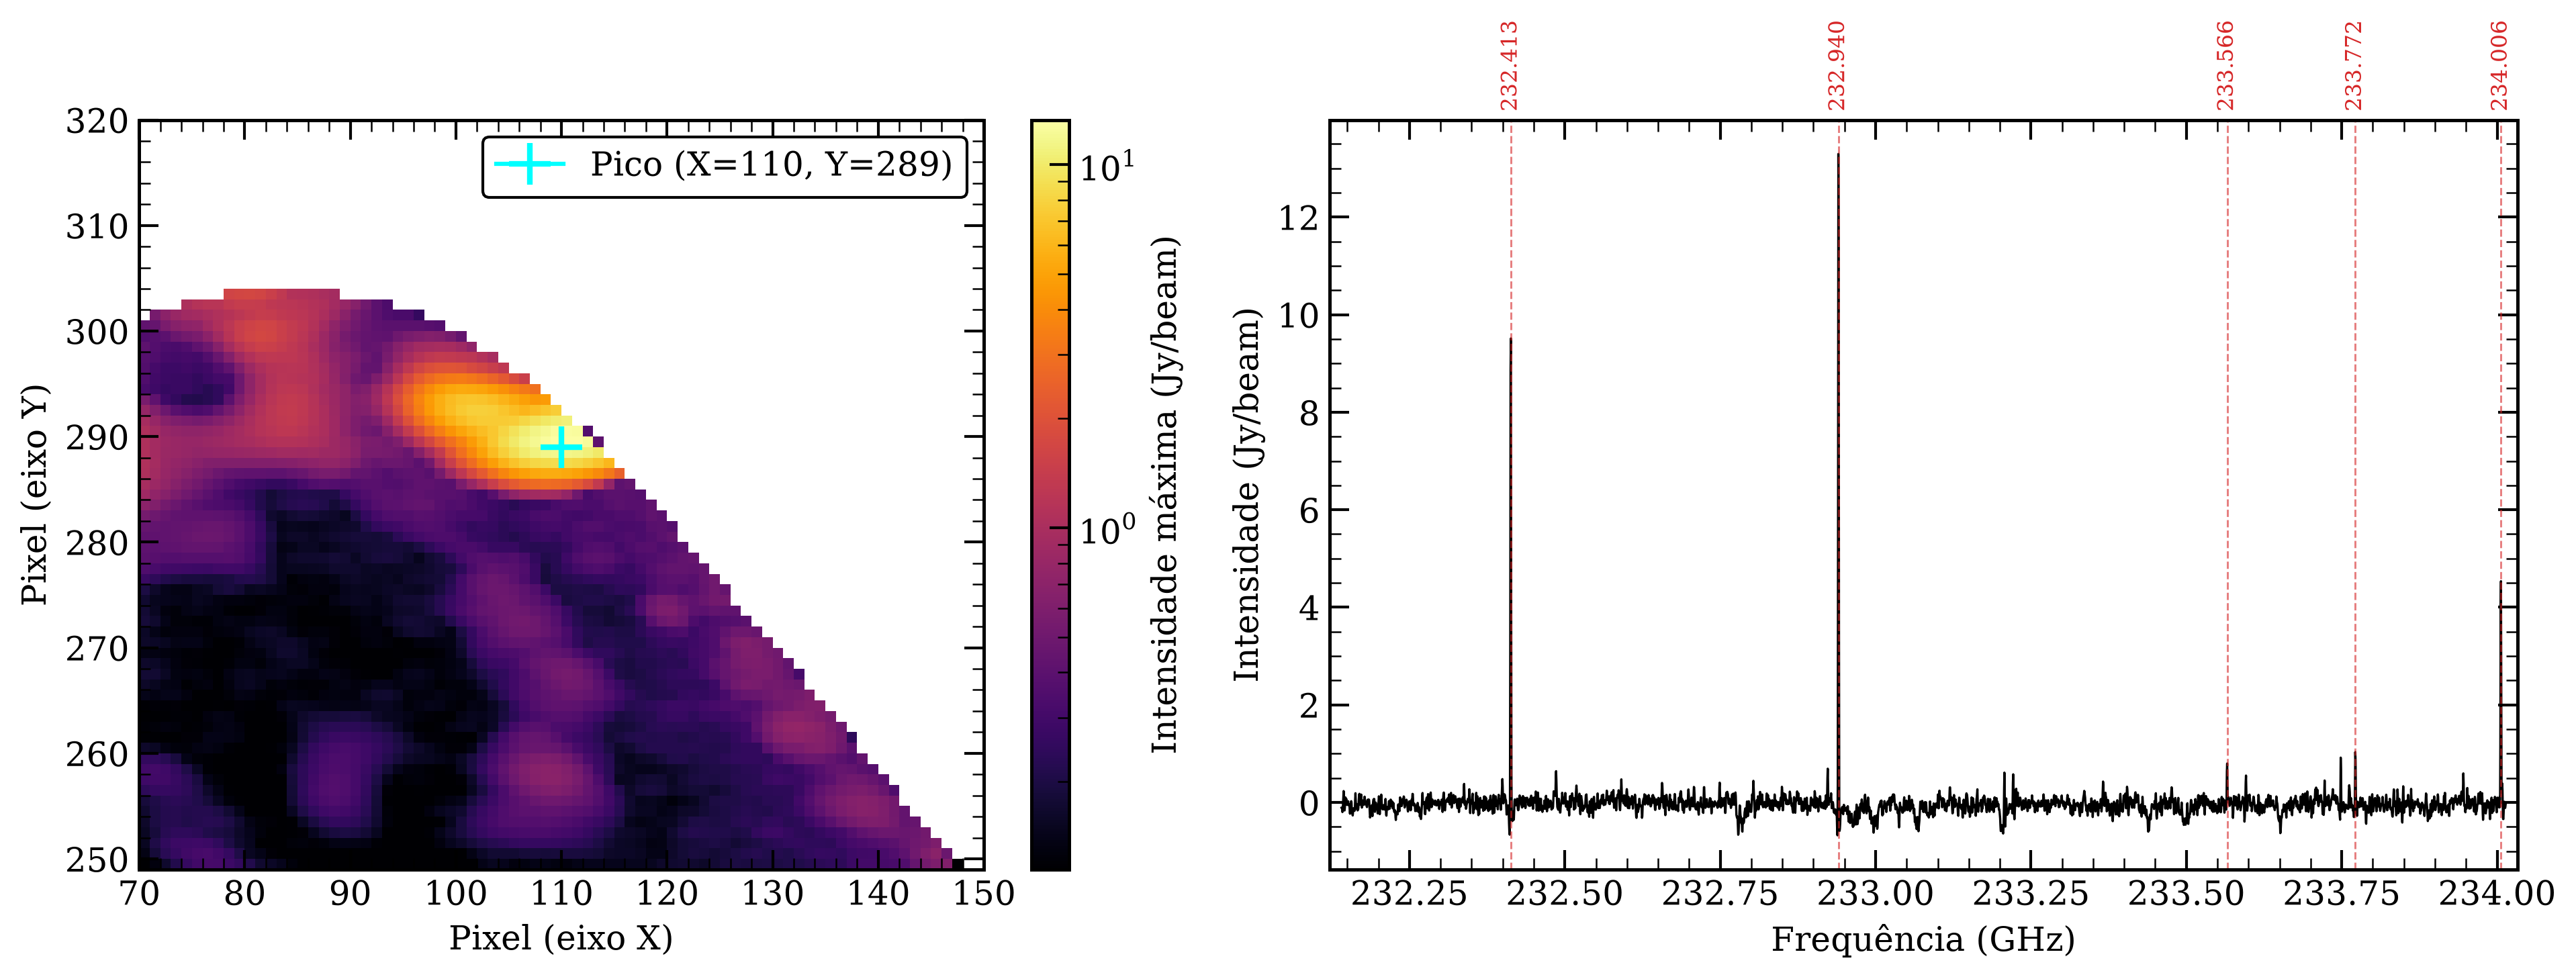

Figura salva em figuras/fig3_mapa_espectro.(png|pdf)


In [8]:
from matplotlib.colors import LogNorm

FREQ_MIN, FREQ_MAX = freq_ghz.min(), freq_ghz.max()
MARGEM_X = 0.01 * (FREQ_MAX - FREQ_MIN)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Painel esquerdo: recorte ao redor da fonte, escala logarítmica ---
margem = 40
y0, y1 = max(0, y_pico - margem), min(mapa_max.shape[0], y_pico + margem)
x0, x1 = max(0, x_pico - margem), min(mapa_max.shape[1], x_pico + margem)
recorte = mapa_max[y0:y1, x0:x1]
vmin = np.nanpercentile(recorte[recorte > 0], 5)
vmax = np.nanmax(recorte)

im = ax1.imshow(recorte, origin="lower", cmap="inferno",
                norm=LogNorm(vmin=max(vmin, 1e-3), vmax=vmax),
                extent=[x0, x1, y0, y1])
ax1.plot(x_pico, y_pico, marker="+", color="cyan", markersize=15,
         markeredgewidth=2.0, label=f"Pico (X={x_pico}, Y={y_pico})")
ax1.set_xlabel("Pixel (eixo X)")
ax1.set_ylabel("Pixel (eixo Y)")
ax1.legend(loc="upper right", frameon=True, framealpha=1.0, edgecolor="black")
cbar = fig.colorbar(im, ax=ax1, label="Intensidade máxima (Jy/beam)",
                    fraction=0.046, pad=0.04)
cbar.ax.tick_params(direction="in")
estilo_sm(ax1)

# --- Painel direito: espectro com picos detectados marcados ---
# Os rótulos de frequência ficam ancorados no topo do quadro (coordenada de eixo,
# não de dado) e na vertical: assim nunca colidem com a moldura nem com picos de
# alturas muito diferentes, mesmo para o pico mais próximo da borda direita. Uma
# pequena margem em x (MARGEM_X) evita que picos nas extremidades fiquem colados
# à moldura.
ax2.plot(freq_ghz, espectro_pico, color="black", linewidth=0.8)
for f, a in zip(freq_picos, alt_picos):
    ax2.axvline(f, color="tab:red", linestyle="--", linewidth=0.7, alpha=0.6)
    ax2.annotate(f"{f:.3f}", xy=(f, 1.0), xycoords=("data", "axes fraction"),
                 xytext=(0, 3), textcoords="offset points",
                 rotation=90, ha="center", va="bottom", fontsize=8,
                 color="tab:red", clip_on=False, annotation_clip=False)
ax2.set_xlabel(r"Frequência (GHz)")
ax2.set_ylabel("Intensidade (Jy/beam)")
ax2.set_xlim(FREQ_MIN - MARGEM_X, FREQ_MAX + MARGEM_X)
ax2.ticklabel_format(useOffset=False, style="plain")
estilo_sm(ax2)

plt.tight_layout()
plt.savefig(os.path.join(PASTA_FIGURAS, "fig3_mapa_espectro.png"))
plt.savefig(os.path.join(PASTA_FIGURAS, "fig3_mapa_espectro.pdf"))
plt.show()
print("Figura salva em figuras/fig3_mapa_espectro.(png|pdf)")


## Etapa 4 — Espectro normalizado com as linhas de emissão

Para visualizar melhor as linhas de emissão, normalizamos o espectro dividindo pelo
seu valor máximo (assim o pico vale 1). O detector encontra **cinco picos** acima do
limiar de 6σ de ruído; anotamos aqui os **três mais intensos** com os nomes das
moléculas que serão identificadas nas próximas etapas — os dois picos remanescentes
(mais fracos, próximos do nível de ruído) não são explorados neste trabalho
preliminar. Esta é a **Figura 2** do artigo.

In [ ]:
espectro_norm = espectro_pico / np.nanmax(np.abs(espectro_pico))

# rótulos por proximidade de frequência de repouso (usa a tabela final)
rotulos = {
    232.400: r"CH$_3$OD",
    232.930: r"CH$_3$COOH",
    234.000: r"blend",
}

def rotulo_mais_proximo(f, tol=0.05):
    """Devolve o rótulo da molécula mais próxima de f (ou "" se nenhuma estiver perto)."""
    chave = min(rotulos, key=lambda k: abs(k - f))
    return rotulos[chave] if abs(chave - f) < tol else ""

# margem em x e alinhamento de rótulo perto das bordas: um pico muito próximo do
# limite do eixo (ex.: o "blend" em 234.00 GHz, praticamente no limite direito)
# teria metade do texto ha="center" projetada para fora do quadro; alinhando à
# direita/esquerda perto das bordas, o rótulo sempre fica totalmente visível.
FREQ_MIN, FREQ_MAX = freq_ghz.min(), freq_ghz.max()
MARGEM_X = 0.01 * (FREQ_MAX - FREQ_MIN)

def alinhamento_horizontal(f):
    frac = (f - FREQ_MIN) / (FREQ_MAX - FREQ_MIN)
    if frac > 0.95:
        return "right"
    if frac < 0.05:
        return "left"
    return "center"

# picos que ganham um inset de zoom: os três de MAIOR fluxo (alt_picos), não os
# três de menor frequência. sorted(freq_picos)[:3] pegava por engano os picos
# 232.41/232.94/233.57 GHz — esse último é um dos dois remanescentes fracos
# (~233.57 e ~233.77 GHz, citados na Etapa 4 como "não explorados"), então seu
# inset ficava sem nome de molécula. Selecionando pelas três maiores alturas
# ficamos com 232.41, 232.94 e 234.00 GHz — exatamente os três picos
# consultados nos catálogos JPL/CDMS na Etapa 5 e presentes em `rotulos`.
picos_top3 = sorted(freq_picos[np.argsort(alt_picos)[-3:]])
picos_com_inset = set(np.round(picos_top3, 6))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(freq_ghz, espectro_norm, color="black", linewidth=0.9)

for f in freq_picos:
    idx = np.argmin(np.abs(freq_ghz - f))
    altura = espectro_norm[idx]
    texto = rotulo_mais_proximo(f)
    tem_inset = round(f, 6) in picos_com_inset
    if tem_inset:
        # o nome da molécula já aparece dentro do próprio inset (evita texto
        # duplicado sobre a caixa do inset); aqui fica só a linha-guia até o pico.
        ax.annotate("", xy=(f, altura), xytext=(f, min(altura + 0.12, 1.05)),
                    arrowprops=dict(arrowstyle="-", lw=0.8, color="black"))
    elif texto:
        ax.annotate(texto, xy=(f, altura), xytext=(f, min(altura + 0.12, 1.05)),
                    ha=alinhamento_horizontal(f), fontsize=11,
                    arrowprops=dict(arrowstyle="-", lw=0.8, color="black"))

ax.set_xlabel(r"Frequência de repouso $\nu$ (GHz)")
ax.set_ylabel(r"Fluxo normalizado ($F_\nu / F_{\mathrm{max}}$)")
ax.set_xlim(FREQ_MIN - MARGEM_X, FREQ_MAX + MARGEM_X)
ax.set_ylim(-0.1, 1.2)
estilo_sm(ax)

# --- Insets: zoom em cada pico principal ---
# O rótulo (frequência + molécula) fica DENTRO do próprio inset (não em
# set_title, que desenha acima e vazaria para a margem da figura maior), e cada
# inset ganha seus próprios rótulos de eixo (ν em GHz; fluxo normalizado) para
# que possa ser lido e entendido de forma independente, como em uma figura
# didática — sem precisar consultar o eixo do gráfico principal.
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# o primeiro inset (i=0) e deslocado um pouco mais para a direita (-0.33 -> -0.27):
# com o valor original, o proprio rotulo/eixo "nu (GHz)" do inset acabava bem em
# cima do pico principal correspondente, no grafico maior, logo abaixo dele.
offsets_x = [-0.27, 0.00, 0.33]
for i, f in enumerate(picos_top3):
    axin = inset_axes(ax, width="20%", height="27%", loc="upper center",
                      bbox_to_anchor=(offsets_x[i], 0, 1, 0.95),
                      bbox_transform=ax.transAxes)
    m = np.abs(freq_ghz - f) < 0.03
    axin.plot(freq_ghz[m], espectro_norm[m], color="black", linewidth=0.8)
    nome_mol = rotulo_mais_proximo(f)
    titulo = f"{f:.3f} GHz" + (f" — {nome_mol}" if nome_mol else "")
    axin.text(0.5, 0.97, titulo, transform=axin.transAxes, ha="center", va="top",
               fontsize=7, bbox=dict(facecolor="white", edgecolor="none",
                                      pad=1.2, alpha=0.85))
    axin.xaxis.set_major_locator(MaxNLocator(nbins=3, prune=None))
    axin.set_xlabel(r"$\nu$ (GHz)", fontsize=6.5, labelpad=1.5)
    axin.set_ylabel(r"$F_\nu/F_{\max}$", fontsize=6.5, labelpad=1.5)
    axin.tick_params(labelsize=6, direction="in")
    axin.ticklabel_format(axis="x", useOffset=False, style="plain")
    axin.margins(x=0)
    for lado in axin.spines.values():
        lado.set_linewidth(0.8)

plt.savefig(os.path.join(PASTA_FIGURAS, "fig2_espectro_normalizado.png"))
plt.savefig(os.path.join(PASTA_FIGURAS, "fig2_espectro_normalizado.pdf"))
plt.show()
print("Figura salva em figuras/fig2_espectro_normalizado.(png|pdf)")

## Etapa 5 — Identificação das moléculas (*Line ID*)

Agora respondemos: **quais moléculas produzem cada linha?** Consultamos os catálogos
internacionais **JPL** (*Jet Propulsion Laboratory*) e **CDMS** (*Cologne Database for
Molecular Spectroscopy*) através da plataforma **Splatalogue**, usando a `astroquery`.

Para cada pico, abrimos uma **janela estreita de frequência** ao redor dele. A janela
precisa ter uma pequena folga porque a nuvem se move (efeito Doppler), deslocando
levemente as frequências observadas em relação às de laboratório.

Cada consulta pode retornar **dezenas a centenas** de transições teoricamente possíveis.
Por isso, aplicamos um **filtro físico**: só faz sentido uma molécula emitir com força se
seu nível de energia superior ($E_u/k$) for compatível com a temperatura do gás. Nos
núcleos quentes de Órion, as temperaturas de excitação vão de ~150 K a ~300 K; adotamos
o limite conservador de **$E_u/k < 500$ K**, abaixo do qual a excitação térmica é
estatisticamente relevante (distribuição de Boltzmann).

In [10]:
import re

COLUNAS = ["name", "chemical_name", "orderedfreq", "upper_state_energy_K"]
LIMITE_ENERGIA_K = 500          # filtro termodinâmico (Boltzmann)
JANELA_MHZ = 20.0               # meia-largura da janela de busca por pico (MHz)

def limpar_nome(texto):
    """Remove marcação HTML e o sufixo vibracional 'v=0' dos nomes do Splatalogue."""
    s = re.sub(r"<[^>]+>", "", str(texto))
    s = s.replace("&alpha;", "α").replace("&Delta;", "Δ").replace("&", "")
    s = re.sub(r"\s*v\s*=\s*0\s*$", "", s)
    return re.sub(r"\s+", " ", s).strip()

def investigar_pico(freq_central_ghz, janela_mhz=JANELA_MHZ, limite_k=LIMITE_ENERGIA_K):
    """Consulta JPL/CDMS numa janela ao redor de freq_central_ghz e aplica o filtro.

    A janela é centrada na frequência OBSERVADA do pico (não na de repouso do
    catálogo): em Orion KL, diferentes transições podem estar deslocadas por até
    ~15-20 km/s em relação ao pico detectado, dependendo do componente cinemático
    (Hot Core, Compact Ridge, Plateau); por isso a meia-largura padrão é 20 MHz —
    larga o suficiente para não perder a transição correta, mas ainda muito mais
    estreita que a banda observada (~2 GHz), evitando confusão de linhas excessiva.
    Retorna um DataFrame filtrado (Eu/k < limite_k) e com nomes limpos, ou None.
    """
    fmin = freq_central_ghz - janela_mhz / 1e3
    fmax = freq_central_ghz + janela_mhz / 1e3
    print(f"Buscando entre {fmin:.4f} e {fmax:.4f} GHz...")
    try:
        tabela = Splatalogue.query_lines(fmin * u.GHz, fmax * u.GHz,
                                         line_lists=["JPL", "CDMS"])
        if len(tabela) == 0:
            print("Nenhuma transição encontrada nesta janela.\n")
            return None
        df = tabela.to_pandas()
        df = df[[c for c in COLUNAS if c in df.columns]].copy()

        if "upper_state_energy_K" in df.columns:
            df = df[df["upper_state_energy_K"] < limite_k]
        if "name" in df.columns:
            df["name"] = df["name"].apply(limpar_nome)
        if "chemical_name" in df.columns:
            df["chemical_name"] = df["chemical_name"].apply(limpar_nome)

        # remove duplicatas exatas (o Splatalogue repete a mesma transição várias vezes)
        df = df.drop_duplicates().reset_index(drop=True)
        if df.empty:
            print(f"Nenhuma molécula sobreviveu ao filtro (Eu/k < {limite_k} K).\n")
            return None
        return df
    except Exception as erro:
        print(f"Erro durante a consulta: {erro}\n")
        return None


### Pico central (232.94 GHz) — o mais intenso

Começamos pela linha mais forte do espectro.

In [11]:
# Centrado na frequência OBSERVADA do pico central (232.9401 GHz), não em um
# valor arredondado a mão — evita o erro de digitar (fmin, fmax) onde a função
# espera (frequência_central, meia_largura).
cand_central = investigar_pico(232.9401)
cand_central


Buscando entre 232.9201 e 232.9601 GHz...


,name,chemical_name,orderedfreq,upper_state_energy_K
0,13CH3CH213CN,Ethyl cyanide,232920.2030,164.37296
1,AA-n-C4H9CN,n-Butyl cyanide,232920.4642,77.00637
2,CH3CONH2 v=1,Acetamide,232920.4933,213.97381
3,CH3CONH2 v=2,Acetamide,232920.6464,99.63070
4,"a-n-C3H7CN, v30 = 1","anti-n-butyronitrile, v30 = 1",232920.7118,260.52031
...,...,...,...,...
178,HC13CN,Cyanomethylene,232959.2926,58.54952
179,H2NCH2COOH - I v=1,Glycine,232959.4008,430.85394
180,NH2CO2CH3 v=1,Methyl Carbamate,232959.9146,299.20130
181,NH2CO2CH3 v=1,Methyl Carbamate,232959.9369,299.20132


### Picos laterais (232.40 GHz e 234.00 GHz)

Repetimos a busca nos outros dois picos. O de 234.00 GHz é um caso interessante de
**sobreposição de linhas** (*blending*): mais de uma molécula pode contribuir para a
mesma frequência observada.

In [12]:
print("=== PICO 1 — 232.41 GHz ===")
cand_pico1 = investigar_pico(232.4132)
display(cand_pico1)

print("=== PICO 3 — 234.01 GHz (possível blend) ===")
cand_pico3 = investigar_pico(234.0062)
display(cand_pico3)


=== PICO 1 — 232.41 GHz ===
Buscando entre 232.3932 e 232.4332 GHz...


,name,chemical_name,orderedfreq,upper_state_energy_K
0,S4,Tetrasulfur,232393.5215,437.18140
1,HCCCH2OD,Propargyl Alcohol,232394.4884,172.26600
2,"CH3O13CHO, vt = 0, 1","Methyl formate, vt = 0, 1",232394.5570,106.49342
3,CH3CH2CH2CN-anti,Butyronitrile,232394.9887,306.42069
4,"n-C3H7CN,","n-Butyronitrile, gauche/anti combined",232395.0055,364.15489
...,...,...,...,...
188,c-C6H5OH,Phenol,232432.2603,301.58754
189,GA-n-C4H9CN,n-Butyl cyanide,232432.3175,495.28214
190,CH313CH2CN,Ethyl Cyanide,232432.6196,177.42482
191,gGG'g-CH2OHCH2CH2OH,"1,3-propanediol, gGG'g",232432.6233,329.70999



=== PICO 3 — 234.01 GHz (possível blend) ===
Buscando entre 233.9862 e 234.0262 GHz...


,name,chemical_name,orderedfreq,upper_state_energy_K
0,ClClOO,Chloryl chloride,233986.7359,249.15913
1,C6H#150;,"1,3,5-Hexatriynyl anion",233987.2403,482.95173
2,H2C(CN)2,Malononitrile,233987.3971,166.77444
3,"n-C3H7CN,","n-Butyronitrile, gauche/anti combined",233988.0001,395.80248
4,O81BrO,Bromine Dioxide,233988.4190,243.03294
...,...,...,...,...
213,13CH313CH213CN,Ethyl cyanide,234025.9250,195.69963
214,E-HNCHCN,Cyanomethanimine,234026.0868,20.76740
215,E-HNCHCN,Cyanomethanimine,234026.1508,20.76740
216,E-HNCHCN,Cyanomethanimine,234026.1606,20.76740


## Etapa 6 — Tabela final das moléculas identificadas

Após a consulta aos catálogos, o filtro termodinâmico e uma triagem contextual
qualitativa (descartando espécies simétricas sem momento de dipolo, isotopólogos muito
raros e moléculas incompatíveis com o ambiente), consolidamos as identificações mais
prováveis. Esta é a **Tabela 1** do artigo, salva também em CSV na pasta de dados.

In [13]:
def linha_por_frequencia(freq_repouso_mhz, tol_mhz=0.05):
    """Procura, nas três consultas já feitas, a transição mais PRÓXIMA da
    frequência de repouso dada (dentro da tolerância).

    Antes esta função devolvia a primeira linha dentro da tolerância — o que
    falhava quando duas transições reais e distintas caem a poucos kHz uma da
    outra (como acontece com os dois candidatos ao blend em 234.00 GHz):
    ambas ficavam associadas à mesma linha por acidente. Agora escolhe-se
    explicitamente a de menor |Δf|.
    """
    melhor, melhor_diff = None, None
    for df in (cand_central, cand_pico1, cand_pico3):
        if df is None or "orderedfreq" not in df.columns:
            continue
        diffs = (df["orderedfreq"] - freq_repouso_mhz).abs()
        candidatos = diffs[diffs < tol_mhz]
        if candidatos.empty:
            continue
        idx_min = candidatos.idxmin()
        if melhor is None or candidatos[idx_min] < melhor_diff:
            melhor = df.loc[idx_min]
            melhor_diff = candidatos[idx_min]
    return melhor

# Identificações escolhidas: (freq de repouso MHz do catálogo, rótulo, freq observada GHz)
escolhas = [
    (232400.31, "Metanol deuterado (CH3OD)",             "~232.40"),
    (232940.37, "Ácido acético (CH3COOH)",                "~232.93"),
    (233999.99, "Glicolaldeído isotópico (13CH2OHCHO)*",  "~234.00"),
    (233999.98, "Ácido monotiofórmico (t-HC(O)SH)*",      "~234.00"),
]

linhas = []
for freq_rep, rotulo, f_obs in escolhas:
    reg = linha_por_frequencia(freq_rep)
    if reg is None:
        print(f"AVISO: {freq_rep} MHz não encontrada nas consultas — aumente tol_mhz.")
        continue
    linhas.append({
        "Molécula identificada": rotulo,
        "Frequência observada (GHz)": f_obs,
        "Frequência de repouso (MHz)": round(float(reg["orderedfreq"]), 2),
        "Energia Eu/k (K)": round(float(reg["upper_state_energy_K"]), 2),
    })

tabela_final = pd.DataFrame(linhas)

caminho_csv = os.path.join(PASTA_DADOS, "tabela_identificacao_moleculas.csv")
tabela_final.to_csv(caminho_csv, index=False, sep=";")
print(f"Tabela salva em {caminho_csv}")
print("(*) Par de candidatas para a linha sobreposta (blend) em 234.00 GHz.\n")
tabela_final


Tabela salva em dados/tabela_identificacao_moleculas.csv
(*) Par de candidatas para a linha sobreposta (blend) em 234.00 GHz.



,Molécula identificada,Frequência observada (GHz),Frequência de repouso (MHz),Energia Eu/k (K)
0,Metanol deuterado (CH3OD),~232.40,232400.31,382.13
1,Ácido acético (CH3COOH),~232.93,232940.37,284.22
2,Glicolaldeído isotópico (13CH2OHCHO)*,~234.00,233999.99,45.23
3,Ácido monotiofórmico (t-HC(O)SH)*,~234.00,233999.98,290.26


## Etapa 7 — Onde fica essa região no céu? (coordenadas celestes)

Por fim, traduzimos a posição do pixel `(110, 289)` em **coordenadas astronômicas reais**
— Ascensão Reta (RA) e Declinação (Dec) — usando novamente o WCS do cabeçalho. Isso
permite confirmar que a "Região 5" está próxima ao centro de **Órion KL**, na fronteira
entre o *Hot Core* e o *Compact Ridge*.

In [14]:
X_REGIAO5, Y_REGIAO5 = 110, 289

wcs_celeste = WCS(header).celestial
coord = wcs_celeste.pixel_to_world(X_REGIAO5, Y_REGIAO5)

print("=== COORDENADAS CELESTES DA REGIÃO 5 ===")
print(f"Pixel X={X_REGIAO5}, Y={Y_REGIAO5}")
print("RA :", coord.ra.to_string(unit="hour", sep="hms", precision=2))
print("Dec:", coord.dec.to_string(unit="degree", sep="dms", precision=2))
print("\n=== Referência: centro de Órion KL ===")
print("RA : 05h35m14s   |   Dec: -05d22m30s")

=== COORDENADAS CELESTES DA REGIÃO 5 ===
Pixel X=110, Y=289
RA : 5h35m14.92s
Dec: -5d22m45.62s

=== Referência: centro de Órion KL ===
RA : 05h35m14s   |   Dec: -05d22m30s


Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


## Encerramento — potencial didático

Este notebook percorreu, em poucas etapas e com ferramentas gratuitas, o mesmo caminho
de uma análise astroquímica profissional: **dado bruto → mapa → espectro → identificação
→ interpretação física → localização no céu**.

Sugestões de uso em sala de aula ou iniciação científica:

- **Química:** discutir por que Moléculas Orgânicas Complexas (COMs) surgem em núcleos
  quentes e o papel do fracionamento de deutério.
- **Física:** relacionar o filtro $E_u/k < 500$ K à distribuição de Boltzmann e ao
  conceito de temperatura de excitação.
- **Computação/Ciência de dados:** explorar como um cubo 3D é manipulado com `numpy` e
  como catálogos científicos são consultados por API.
- **Atividade proposta:** trocar a janela de frequência ou o limite de energia e observar
  como o conjunto de moléculas candidatas muda — uma forma concreta de discutir critérios
  de decisão em ciência.

> **Limitação honesta:** a identificação a partir de um único espectro é *preliminar*. A
> confirmação de uma molécula no meio interestelar exige múltiplas linhas de transição e
> consistência espacial — um ótimo ponto de partida para discutir o método científico.